##### NOTEBOOK 5 — MODELO SVM-RBF
##### TFM: Integración QML en pipeline DataOps
##### Juan Albornoz Carrasco — Universidad Europea de Valencia
##### Lee desde Gold Parquet — Guarda modelo y metricas en Volumes


##### CELDA 1 — Instalación de dependencias
##### Ejecutar solo cuando las librerías no estén disponibles

In [0]:
#%pip install scikit-learn joblib
#%pip install skl2onnx onnx onnxruntime --quiet

##### CELDA 2 — Reinicio del kernel

In [0]:
dbutils.library.restartPython()

##### CELDA 3 — Imports

In [0]:
import os
import joblib
import numpy as np
import pandas as pd
import onnxruntime as rt
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from skl2onnx import convert_sklearn
from matplotlib.colors import LinearSegmentedColormap
from skl2onnx.common.data_types import FloatTensorType

from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    matthews_corrcoef, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)
import warnings
warnings.filterwarnings("ignore")
print("Imports OK")

Imports OK


In [0]:
gold_dir   = "/Volumes/workspace/default/nhanes/gold"
models_dir = "/Volumes/workspace/default/nhanes/models"
os.makedirs(models_dir, exist_ok=True)

##### CELDA 4 — Cargar datasets Gold SVM

In [0]:
X_train = pd.read_parquet(f"{gold_dir}/X_train_svm.parquet")
X_test  = pd.read_parquet(f"{gold_dir}/X_test_svm.parquet")
y_train = pd.read_parquet(f"{gold_dir}/y_train_svm.parquet").squeeze()
y_test  = pd.read_parquet(f"{gold_dir}/y_test_svm.parquet").squeeze()

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Distribucion train: {y_train.value_counts().to_dict()}")
print(f"Distribucion test:  {y_test.value_counts().to_dict()}")

Train: (6264, 89), Test: (1567, 89)
Distribucion train: {0: 5385, 1: 879}
Distribucion test:  {0: 1347, 1: 220}


##### CELDA 5 — Entrenamiento SVM con kernel RBF
##### Parametros: C=1.0, gamma=scale, class_weight=balanced

In [0]:
svm_model = SVC(
    kernel="rbf",
    class_weight="balanced",
    probability=True,
    random_state=42,
    C=1.0,
    gamma="scale"
)

svm_model.fit(X_train, y_train)
print("SVM-RBF entrenado correctamente")
print(f"Parametros: kernel=rbf, C=1.0, gamma=scale, class_weight=balanced")

SVM-RBF entrenado correctamente
Parametros: kernel=rbf, C=1.0, gamma=scale, class_weight=balanced


##### CELDA 6 — Evaluacion sobre conjunto de test

In [0]:
y_pred = svm_model.predict(X_test)
y_prob = svm_model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)
f1  = f1_score(y_test, y_pred, average="macro")
acc = accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)

print("=== METRICAS SVM-RBF ===")
print(f"AUC-ROC:  {auc:.4f}")
print(f"F1-macro: {f1:.4f}")
print(f"Accuracy: {acc:.4f}")
print(f"MCC:      {mcc:.4f}")
print(f"\nReporte detallado:")
print(classification_report(y_test, y_pred, target_names=["No diabetes", "Diabetes"]))

=== METRICAS SVM-RBF ===
AUC-ROC:  0.9377
F1-macro: 0.8243
Accuracy: 0.9075
MCC:      0.6539

Reporte detallado:
              precision    recall  f1-score   support

 No diabetes       0.96      0.93      0.95      1347
    Diabetes       0.64      0.78      0.70       220

    accuracy                           0.91      1567
   macro avg       0.80      0.85      0.82      1567
weighted avg       0.92      0.91      0.91      1567



##### CELDA 7 — Curva ROC

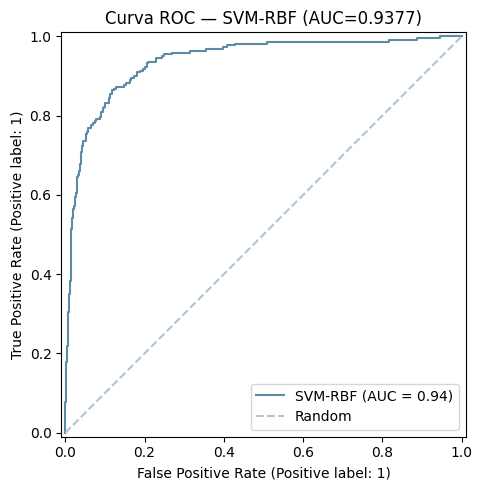

In [0]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    y_test, y_prob,
    ax=ax,
    name="SVM-RBF",
    color="#5D8BA6"
)
ax.plot([0, 1], [0, 1], "--", color="#AEC5D2", label="Random")
ax.set_title(f"Curva ROC — SVM-RBF (AUC={auc:.4f})")
ax.legend()
plt.tight_layout()
plt.savefig(f"{models_dir}/roc_svm.png", dpi=150)
plt.show()

##### CELDA 8 — Matriz de confusion

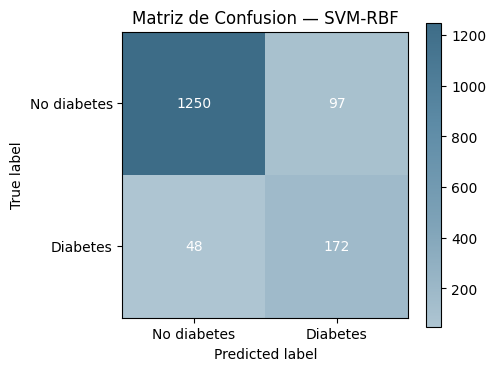

In [0]:
colores_hex = [
    "#AEC5D2", 
    "#7FA3B8", 
    "#5D8BA6", 
    "#3D6C87"
]
mi_paleta = LinearSegmentedColormap.from_list("mi_paleta_azul", colores_hex)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["No diabetes", "Diabetes"],
    ax=ax, colorbar=True,
    cmap=mi_paleta,
    text_kw={"color": "white"} 
)
ax.set_title("Matriz de Confusion — SVM-RBF")
plt.tight_layout()
plt.savefig(f"{models_dir}/confusion_svm.png", dpi=150)
plt.show()

##### CELDA 9 — Guardar modelo y metricas

In [0]:
# Guardar modelo
joblib.dump(svm_model, f"{models_dir}/svm_rbf_final.pkl")
print(f"Modelo guardado: {models_dir}/svm_rbf_final.pkl")

# Guardar metricas
metricas_svm = {
    "modelo":   "SVM-RBF",
    "auc_roc":  round(auc, 4),
    "f1_macro": round(f1, 4),
    "accuracy": round(acc, 4),
    "mcc":      round(mcc, 4),
    "params":   {"kernel": "rbf", "C": 1.0, "gamma": "scale"}
}

pd.DataFrame([metricas_svm]).to_csv(f"{models_dir}/metricas_svm.csv", index=False)
print(f"Metricas guardadas: {models_dir}/metricas_svm.csv")
print("\nResumen final:")
print(metricas_svm)

Modelo guardado: /Volumes/workspace/default/nhanes/models/svm_rbf_final.pkl
Metricas guardadas: /Volumes/workspace/default/nhanes/models/metricas_svm.csv

Resumen final:
{'modelo': 'SVM-RBF', 'auc_roc': np.float64(0.9377), 'f1_macro': 0.8243, 'accuracy': 0.9075, 'mcc': np.float64(0.6539), 'params': {'kernel': 'rbf', 'C': 1.0, 'gamma': 'scale'}}


##### CELDA 10 — Serialización ONNX y verificación — SVM-RBF

In [0]:
# Convertir a ONNX
n_features = X_train.shape[1]
initial_type = [("float_input", FloatTensorType([None, n_features]))]

onnx_model = convert_sklearn(
    svm_model,
    initial_types=initial_type,
    target_opset=12
)

# Guardar
onnx_path = f"{models_dir}/svm_final.onnx"
with open(onnx_path, "wb") as f:
    f.write(onnx_model.SerializeToString())

print(f"Modelo ONNX guardado: {onnx_path}")
print(f"Tamaño: {os.path.getsize(onnx_path) / 1024:.1f} KB")

# Verificar que ONNX produce mismas predicciones que PKL
rt.set_default_logger_severity(3)   # ← añadir esta línea
sess = rt.InferenceSession(onnx_path)
input_name = sess.get_inputs()[0].name
y_pred_onnx = sess.run(None, {
    input_name: X_test.values.astype(np.float32)
})[0]

coincidencias = (y_pred_onnx == y_pred).mean()
print(f"\nCoincidencia PKL vs ONNX: {coincidencias*100:.1f}%")
print("ONNX verificado OK" if coincidencias == 1.0 else "ADVERTENCIA: diferencias detectadas")

Modelo ONNX guardado: /Volumes/workspace/default/nhanes/models/svm_final.onnx
Tamaño: 1038.7 KB

Coincidencia PKL vs ONNX: 100.0%
ONNX verificado OK


##### CELDA 11 — Validacion final SVM-RBF

In [0]:
print("=== VALIDACION FINAL SVM-RBF ===")

print(f"\n1. Modelo guardado:")
df_check = pd.read_csv(f"{models_dir}/metricas_svm.csv")
print(df_check.to_string(index=False))

print(f"\n2. Artefactos generados:")
artefactos = [
    "svm_rbf_final.pkl",
    "svm_final.onnx",
    "metricas_svm.csv",
    "roc_svm.png",
    "confusion_svm.png"
]
for artefacto in artefactos:
    existe = os.path.exists(f"{models_dir}/{artefacto}")
    tam = os.path.getsize(f"{models_dir}/{artefacto}") / 1024 if existe else 0
    estado = f"OK ({tam:.1f} KB)" if existe else "❌ FALTA"
    print(f"   {artefacto}: {estado}")

print("\n=== SVM-RBF COMPLETADO OK ===")

=== VALIDACION FINAL SVM-RBF ===

1. Modelo guardado:
 modelo  auc_roc  f1_macro  accuracy    mcc                                        params
SVM-RBF   0.9377    0.8243    0.9075 0.6539 {'kernel': 'rbf', 'C': 1.0, 'gamma': 'scale'}

2. Artefactos generados:
   svm_rbf_final.pkl: OK (1691.7 KB)
   svm_final.onnx: OK (1038.7 KB)
   metricas_svm.csv: OK (0.1 KB)
   roc_svm.png: OK (50.6 KB)
   confusion_svm.png: OK (35.3 KB)

=== SVM-RBF COMPLETADO OK ===
